# VIX Distribution, Stress Events, and Rolling Risk

This notebook validates VIX as one input to the composite market-risk
indicator. It follows the same analytical structure as the SKEW validation:

1. compare Raw VIX and Log VIX;
2. identify the structural source of full-sample non-normality;
3. separate ordinary daily states from strategy-defined stress events;
4. apply the same current-inclusive two-stage 120-month rolling calculation
   used by SKEW.

Daily **Close** is the primary distribution series because it preserves the
time spent at each VIX level. Daily **High** is used only to reproduce the
existing event classification. Monthly **Close** is used only for the
composite model's ten-year rolling parameter.

> **Live-data notebook.** Run all cells to refresh the tables and charts from a
> single UTC execution timestamp. The saved outputs are a validated research
> snapshot; Git history preserves earlier snapshots.

In [1]:
from pathlib import Path
import sys
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
import yfinance.cache as yf_cache
from scipy import stats

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = Path.cwd().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.market_risk.vix import (
    classify_vix_stress_events,
    compute_vix_risk_frame,
    prepare_vix_observations,
)

RUN_TIMESTAMP_UTC = pd.Timestamp.now(tz="UTC")
ROLLING_MONTHS = 120
EVENT_WINDOW_MONTHS = 360
REPORT_DIR = REPO_ROOT / "reports/generated/vix_distribution"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Notebook run timestamp (UTC): {RUN_TIMESTAMP_UTC.isoformat()}")


def distribution_stats(series, name):
    clean = series.dropna().astype(float)
    sample = clean.sample(5000, random_state=42) if len(clean) > 5000 else clean
    shapiro_stat, shapiro_p = stats.shapiro(sample)
    jb = stats.jarque_bera(clean)
    standardized = (clean - clean.mean()) / clean.std()
    ks = stats.kstest(standardized, "norm")
    return pd.Series({
        "Name": name,
        "Count": len(clean),
        "Mean": clean.mean(),
        "Std": clean.std(),
        "Median": clean.median(),
        "Skewness": stats.skew(clean),
        "Kurtosis_Excess": stats.kurtosis(clean),
        "Lag1_Autocorrelation": clean.autocorr(lag=1),
        "Shapiro_Stat": shapiro_stat,
        "Shapiro_p": shapiro_p,
        "Jarque_Bera_p": jb.pvalue,
        "KS_D_vs_Fitted_Normal": ks.statistic,
    })

Notebook run timestamp (UTC): 2026-07-28T06:05:43.938793+00:00


## Data preparation

The notebook downloads one daily VIX history and derives every series from that
same run:

- daily Close for Raw/Log distribution analysis;
- daily High for the existing point-in-time stress-event classification;
- completed-month Close for historical rolling diagnostics;
- latest daily Close as the provisional current-month model input.

High and Close are validated independently. An invalid High never removes an
otherwise valid Close. A Close whose High-based event state is unavailable is
retained in the full Close distribution and rolling model, but excluded from
the event-versus-ordinary decomposition.

In [2]:
yf_cache.set_cache_location(tempfile.mkdtemp(prefix="vix-analysis-"))
today = RUN_TIMESTAMP_UTC.tz_localize(None).normalize()
end_exclusive = (today + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

raw = yf.download(
    "^VIX",
    start="1990-01-01",
    end=end_exclusive,
    auto_adjust=False,
    progress=False,
)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

daily_close, daily_high, source_diagnostics = prepare_vix_observations(raw)
daily_log = np.log(daily_close).rename("Log_VIX_Close")

monthly_all = daily_close.resample("ME").last().dropna()
current_month_end = today + pd.offsets.MonthEnd(0)
completed_monthly = monthly_all.loc[monthly_all.index < current_month_end].copy()
model_monthly = completed_monthly.copy()
model_monthly.loc[current_month_end] = daily_close.iloc[-1]
model_monthly = model_monthly.sort_index()

classified_daily, events = classify_vix_stress_events(
    daily_high.to_frame(),
    high_col="VIX_High",
    window_months=EVENT_WINDOW_MONTHS,
    exit_consecutive_days=10,
)
event_state = classified_daily["In_Stress_Event"].reindex(daily_close.index)
ordinary_daily_close = daily_close.loc[event_state.eq(False)]
ordinary_daily_log = np.log(ordinary_daily_close).rename("Ordinary_Log_VIX")

print(f"Close sample: {daily_close.index.min().date()} to {daily_close.index.max().date()}")
print(f"High sample: {daily_high.index.min().date()} to {daily_high.index.max().date()}")
print(f"Completed-month sample: {completed_monthly.index.min().date()} to {completed_monthly.index.max().date()}")
print(f"Provisional model month: {current_month_end.date()} using {daily_close.index[-1].date()} Close")
display(source_diagnostics.rename("Count").to_frame())
print(f"Stress events: {len(events)}")
print(f"Event trading days removed from ordinary-state distribution: {int(classified_daily['In_Stress_Event'].sum())}")
print(f"Valid Close days omitted because event state is unavailable: {int(event_state.isna().sum())}")

Close sample: 1990-01-02 to 2026-07-27
High sample: 1990-01-02 to 2026-07-27
Completed-month sample: 1990-01-31 to 2026-06-30
Provisional model month: 2026-07-31 using 2026-07-27 Close


,Count
High_Missing,0
High_Nonpositive,0
Close_Missing,0
Close_Nonpositive,0
Valid_Close_Without_Valid_High,0


Stress events: 12
Event trading days removed from ordinary-state distribution: 535
Valid Close days omitted because event state is unavailable: 0


## Raw VIX and Log VIX

Raw VIX has a long right tail because volatility shocks are positive,
asymmetric, and occasionally extreme. The logarithm preserves ordering while
compressing large spikes and converting multiplicative changes into additive
differences.

Means and standard deviations are not compared across Raw and Log units.
Shape improvement is evaluated with skewness, excess kurtosis, Q-Q behavior,
and the maximum CDF distance from a fitted normal distribution.

In [3]:
raw_log_summary = pd.DataFrame([
    distribution_stats(daily_close, "Raw daily VIX Close"),
    distribution_stats(daily_log, "Log daily VIX Close"),
])
display(raw_log_summary)

shape_effect = pd.DataFrame({
    "Raw": raw_log_summary.set_index("Name").loc["Raw daily VIX Close"],
    "Log": raw_log_summary.set_index("Name").loc["Log daily VIX Close"],
}).loc[[
    "Skewness",
    "Kurtosis_Excess",
    "Shapiro_Stat",
    "KS_D_vs_Fitted_Normal",
]]
display(shape_effect)

,Name,Count,Mean,Std,Median,Skewness,Kurtosis_Excess,Lag1_Autocorrelation,Shapiro_Stat,Shapiro_p,Jarque_Bera_p,KS_D_vs_Fitted_Normal
0,Raw daily VIX Close,9208,19.450034,7.737679,17.610001,2.210297,8.746036,0.976817,0.833144,3.247462e-58,0.000000e+00,0.108685
1,Log daily VIX Close,9208,2.905228,0.340353,2.868467,0.668316,0.518789,0.979916,0.970317,5.754365e-31,5.405424e-172,0.047641


,Raw,Log
Skewness,2.210297,0.668316
Kurtosis_Excess,8.746036,0.518789
Shapiro_Stat,0.833144,0.970317
KS_D_vs_Fitted_Normal,0.108685,0.047641


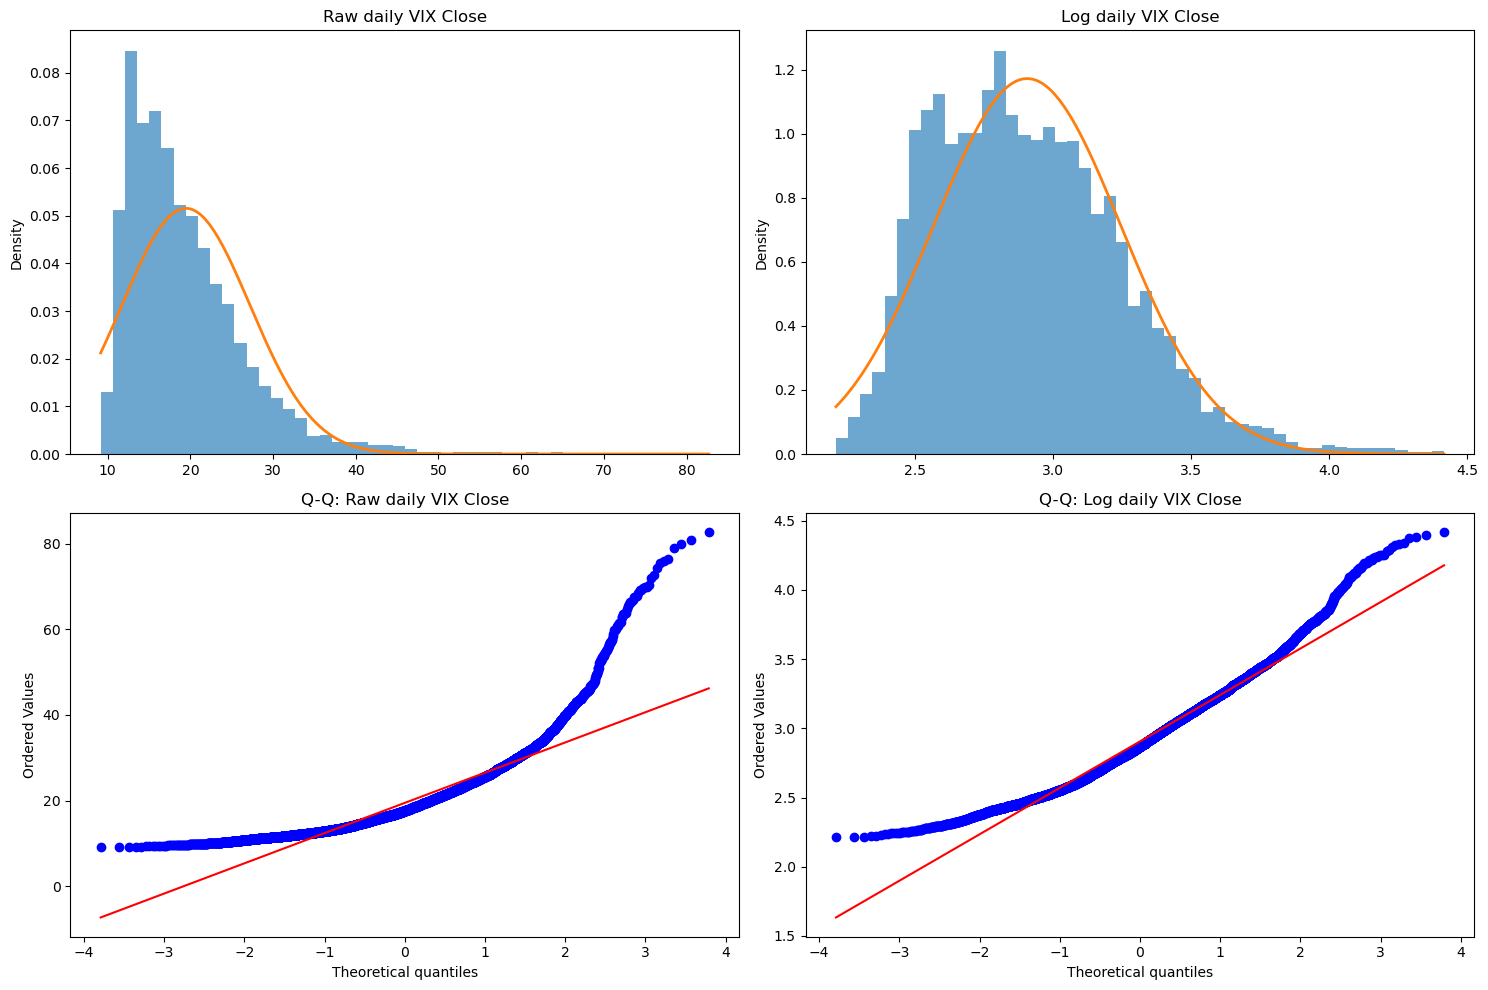

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for axis, series, title in [
    (axes[0, 0], daily_close, "Raw daily VIX Close"),
    (axes[0, 1], daily_log, "Log daily VIX Close"),
]:
    clean = series.dropna()
    axis.hist(clean, bins=50, density=True, alpha=0.65)
    x = np.linspace(clean.min(), clean.max(), 300)
    axis.plot(x, stats.norm.pdf(x, clean.mean(), clean.std()), linewidth=2)
    axis.set_title(title)
    axis.set_ylabel("Density")

stats.probplot(daily_close, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q: Raw daily VIX Close")
stats.probplot(daily_log, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q: Log daily VIX Close")

plt.tight_layout()
fig.savefig(REPORT_DIR / "distribution_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

### Saved Raw/Log chart

![Raw and Log VIX distribution diagnostics](../../reports/generated/vix_distribution/distribution_diagnostics.png)

## Event-driven right tail

The existing VIX strategy supplies the event definition; this notebook does not
invent a second threshold.

- event start: completed daily VIX High above the point-in-time +2 sigma line;
- event end: ten consecutive completed daily High observations below +1 sigma;
- early history: the strategy's intentional retrospective first complete
  360-month baseline;
- later history: 359 completed monthly highs plus the current month-to-date
  High.

The event state is used here only to separate the ordinary daily VIX
distribution from the stress component that creates much of the right tail.

In [5]:
display(events)

event_distribution_summary = pd.DataFrame([
    distribution_stats(daily_close, "All daily Raw VIX"),
    distribution_stats(daily_log, "All daily Log VIX"),
    distribution_stats(ordinary_daily_close, "Ordinary daily Raw VIX"),
    distribution_stats(ordinary_daily_log, "Ordinary daily Log VIX"),
])
display(event_distribution_summary[[
    "Name",
    "Count",
    "Mean",
    "Std",
    "Skewness",
    "Kurtosis_Excess",
    "Lag1_Autocorrelation",
    "Shapiro_Stat",
    "KS_D_vs_Fitted_Normal",
]])

,Event_ID,Event_Start_Date,Event_End_Date,Max_VIX_Date,Max_VIX
0,1,1997-10-28,1997-12-01,1997-10-28,48.639999
1,2,1998-08-31,1998-11-05,1998-10-08,49.529999
2,3,2001-09-17,2001-11-15,2001-09-21,49.349998
3,4,2002-07-23,2002-08-28,2002-07-24,48.459999
4,5,2008-09-29,2009-05-21,2008-10-24,89.529999
5,6,2010-05-20,2010-06-23,2010-05-21,48.200001
6,7,2011-08-08,2011-12-09,2011-08-08,48.000000
7,8,2015-08-24,2015-09-10,2015-08-24,53.290001
8,9,2018-02-06,2018-02-26,2018-02-06,50.299999
9,10,2020-02-28,2020-05-29,2020-03-18,85.470001


,Name,Count,Mean,Std,Skewness,Kurtosis_Excess,Lag1_Autocorrelation,Shapiro_Stat,KS_D_vs_Fitted_Normal
0,All daily Raw VIX,9208,19.450034,7.737679,2.210297,8.746036,0.976817,0.833144,0.108685
1,All daily Log VIX,9208,2.905228,0.340353,0.668316,0.518789,0.979916,0.970317,0.047641
2,Ordinary daily Raw VIX,8673,18.255578,5.530367,0.858581,0.476299,0.967434,0.944602,0.081675
3,Ordinary daily Log VIX,8673,2.861294,0.291153,0.243700,-0.650409,0.973317,0.985219,0.045926


## Event-frequency structural change

The structural question for VIX differs from SKEW. SKEW shows a persistent
post-crisis rise in level and dispersion. VIX does not show the same monotonic
ordinary-state level shift. Instead, the stress-event classification indicates
a change in how often the market moves from the ordinary state into the right
tail.

Because VIX is strongly autocorrelated, an event contributes not only a start
date but also a duration. The rolling model therefore absorbs event frequency,
magnitude, duration, and time spent in persistent high- or low-VIX states.

In [6]:
split_date = pd.Timestamp("2008-01-01")
sample_start = classified_daily.index.min()
sample_end = classified_daily.index.max()

frequency_rows = []
for label, start, end in [
    ("1990-2007", sample_start, pd.Timestamp("2007-12-31")),
    ("2008-present", split_date, sample_end),
]:
    event_starts = pd.to_datetime(events["Event_Start_Date"])
    count = int(((event_starts >= start) & (event_starts <= end)).sum())
    years = (end - start).days / 365.2425
    frequency_rows.append({
        "Period": label,
        "Events": count,
        "Years": years,
        "Events_Per_Year": count / years,
    })

event_frequency = pd.DataFrame(frequency_rows)
display(event_frequency)

ordinary_pre = ordinary_daily_log.loc[:"2007-12-31"]
ordinary_post = ordinary_daily_log.loc["2008-01-01":]
ordinary_periods = pd.DataFrame([
    distribution_stats(ordinary_pre, "Ordinary Log VIX, 1990-2007"),
    distribution_stats(ordinary_post, "Ordinary Log VIX, 2008-present"),
])
display(ordinary_periods[[
    "Name",
    "Count",
    "Mean",
    "Std",
    "Median",
    "Skewness",
    "Kurtosis_Excess",
]])

annual_ordinary = ordinary_daily_log.groupby(ordinary_daily_log.index.year).mean()
annual_pre = annual_ordinary.loc[:2007]
annual_post = annual_ordinary.loc[2008:]
annual_tests = pd.Series({
    "Pre_annual_observations": len(annual_pre),
    "Post_annual_observations": len(annual_post),
    "Pre_mean_annual_Log_VIX": annual_pre.mean(),
    "Post_mean_annual_Log_VIX": annual_post.mean(),
    "Post_minus_pre": annual_post.mean() - annual_pre.mean(),
    "Geometric_mean_ratio": np.exp(annual_post.mean() - annual_pre.mean()),
    "Welch_mean_p": stats.ttest_ind(annual_pre, annual_post, equal_var=False).pvalue,
    "Mann_Whitney_p": stats.mannwhitneyu(
        annual_pre,
        annual_post,
        alternative="two-sided",
    ).pvalue,
})
display(annual_tests.to_frame("value"))

,Period,Events,Years,Events_Per_Year
0,1990-2007,4,17.993525,0.222302
1,2008-present,8,18.568485,0.430838


,Name,Count,Mean,Std,Median,Skewness,Kurtosis_Excess
0,"Ordinary Log VIX, 1990-2007",4395,2.870050,0.302011,2.857619,0.217162,-0.797967
1,"Ordinary Log VIX, 2008-present",4278,2.852299,0.279309,2.829678,0.261329,-0.481824


,value
Pre_annual_observations,18.000000
Post_annual_observations,19.000000
Pre_mean_annual_Log_VIX,2.879159
Post_mean_annual_Log_VIX,2.871277
Post_minus_pre,-0.007881
Geometric_mean_ratio,0.992150
Welch_mean_p,0.922149
Mann_Whitney_p,0.987878


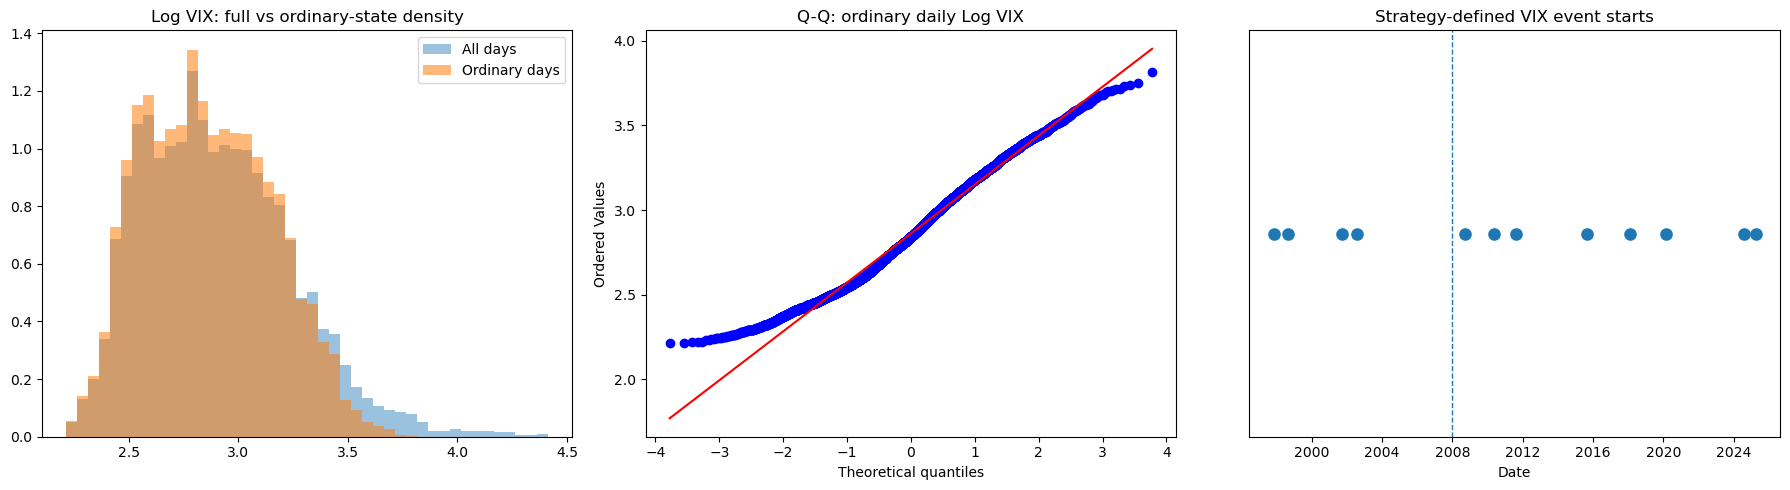

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bins = np.linspace(
    min(daily_log.min(), ordinary_daily_log.min()),
    max(daily_log.max(), ordinary_daily_log.max()),
    45,
)
axes[0].hist(daily_log, bins=bins, density=True, alpha=0.45, label="All days")
axes[0].hist(ordinary_daily_log, bins=bins, density=True, alpha=0.55, label="Ordinary days")
axes[0].set_title("Log VIX: full vs ordinary-state density")
axes[0].legend()

stats.probplot(ordinary_daily_log, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q: ordinary daily Log VIX")

event_starts = pd.to_datetime(events["Event_Start_Date"])
axes[2].scatter(event_starts, np.ones(len(event_starts)), s=65)
axes[2].axvline(split_date, linestyle="--", linewidth=1)
axes[2].set_yticks([])
axes[2].set_title("Strategy-defined VIX event starts")
axes[2].set_xlabel("Date")

plt.tight_layout()
fig.savefig(REPORT_DIR / "event_structure.png", dpi=150, bbox_inches="tight")
plt.show()

### Saved event-structure chart

![VIX event structure and ordinary-state distribution](../../reports/generated/vix_distribution/event_structure.png)

## Same two-stage rolling calculation as SKEW

The composite VIX parameter now uses the same operation as the validated SKEW
parameter:

1. transform monthly Close with the natural logarithm;
2. calculate `(Log VIX - trailing 120-month Log mean) / trailing 120-month Log mean`;
3. calculate the trailing 120-month mean and standard deviation of that
   deviation;
4. standardize the current deviation into a rolling Z-score;
5. map the Z-score through the standard-normal CDF to a bounded score.

Both windows include the current month. Event observations are intentionally
retained. Their changing frequency, magnitude, duration, and persistence are
part of the recent VIX environment against which the current observation is
evaluated.

The transformation is not expected to make the combined ordinary/event
mixture normal. Its purpose is to measure the current location relative to the
recent composite environment.

In [8]:
model = compute_vix_risk_frame(
    model_monthly.to_frame("VIX_Close"),
    window=ROLLING_MONTHS,
)
model["Normal_Risk_Score_Pct"] = model["Normal_Risk_Score"] * 100
valid_z = model["Z_Score"].dropna()
model_summary = distribution_stats(valid_z, "Composite-model VIX Z")
display(model_summary[[
    "Name",
    "Count",
    "Mean",
    "Std",
    "Skewness",
    "Kurtosis_Excess",
    "Lag1_Autocorrelation",
    "Shapiro_Stat",
    "KS_D_vs_Fitted_Normal",
]])

latest_model = model.dropna(subset=["Z_Score"]).iloc[-1]
print(f"Latest VIX Close: {latest_model['VIX_Close']:.4f}")
print(f"Latest Log deviation: {latest_model['Log_Deviation']:.6f}")
print(f"Latest rolling Z-score: {latest_model['Z_Score']:.4f}")
print(f"Latest bounded normal-score: {latest_model['Normal_Risk_Score_Pct']:.2f}%")

Name                     Composite-model VIX Z
Count                                      201
Mean                                   0.05765
Std                                   0.982232
Skewness                              1.105975
Kurtosis_Excess                       2.256204
Lag1_Autocorrelation                  0.771707
Shapiro_Stat                          0.938531
KS_D_vs_Fitted_Normal                 0.100062
dtype: object

Latest VIX Close: 18.6700
Latest Log deviation: 0.019979
Latest rolling Z-score: 0.1246
Latest bounded normal-score: 54.96%


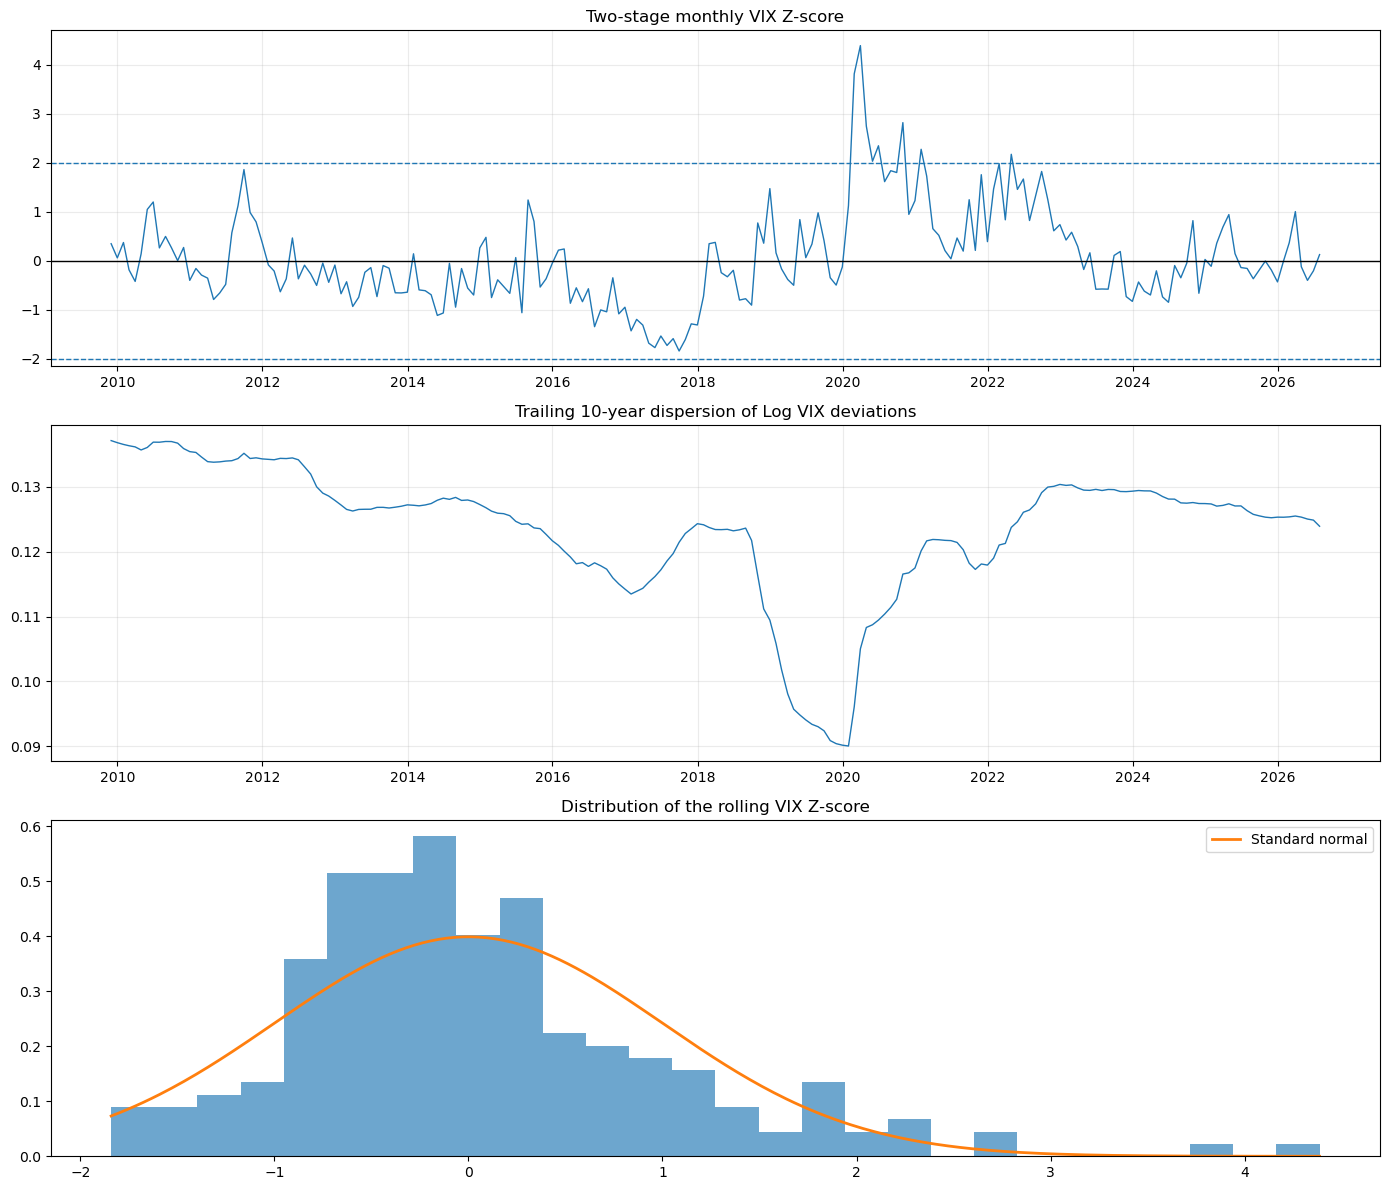

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(model.index, model["Z_Score"], linewidth=1)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].axhline(2, linestyle="--", linewidth=1)
axes[0].axhline(-2, linestyle="--", linewidth=1)
axes[0].set_title("Two-stage monthly VIX Z-score")
axes[0].grid(alpha=0.25)

axes[1].plot(model.index, model["Dev_10Y_Std"], linewidth=1)
axes[1].set_title("Trailing 10-year dispersion of Log VIX deviations")
axes[1].grid(alpha=0.25)

axes[2].hist(valid_z, bins=28, density=True, alpha=0.65)
x = np.linspace(valid_z.min(), valid_z.max(), 300)
axes[2].plot(x, stats.norm.pdf(x), linewidth=2, label="Standard normal")
axes[2].set_title("Distribution of the rolling VIX Z-score")
axes[2].legend()

plt.tight_layout()
fig.savefig(REPORT_DIR / "rolling_model_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

### Saved rolling-model chart

![VIX two-stage rolling-model diagnostics](../../reports/generated/vix_distribution/rolling_model_diagnostics.png)

## Interpretation boundary

The evidence supports the following measurement model:

- Raw VIX is strongly right-tailed;
- Log VIX materially improves the distribution's central shape;
- strategy-defined stress events create much of the remaining right tail;
- ordinary daily Log VIX is substantially closer to normal, though still
  serially dependent and not exactly IID normal;
- the post-crisis structural change appears primarily in stress-event
  frequency and state occupancy rather than a permanent one-way rise in the
  ordinary VIX center;
- the two-stage rolling calculation intentionally combines ordinary and event
  states to evaluate the current monthly Close relative to the recent market
  environment.

The normal-CDF output is a bounded relative score. It is not a crash
probability, an empirical rank, or proof that the transformed series is
standard normal.

Trading entries, wave rules, portfolio accounting, and forward-return
performance remain in the separate VIX event-strategy analysis.